In [1]:
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from models import Lorenz63Model
from filters import GaussianMixture

In [2]:
model_parameters = {
    'sigma': 10.0, 
    'rho': 28.0, 
    'beta': 8.0 / 3.0, 
    'initial_condition': [1.508870, -1.531271, 25.46091],
    'end_time': 40,
    'time_step': 0.0001, 
    'noise_mean': 0, 
    'noise_variance': 2, 
    'observation_time_step': 0.5,
    'ensemble_size': 2000
}

model = Lorenz63Model(**model_parameters)


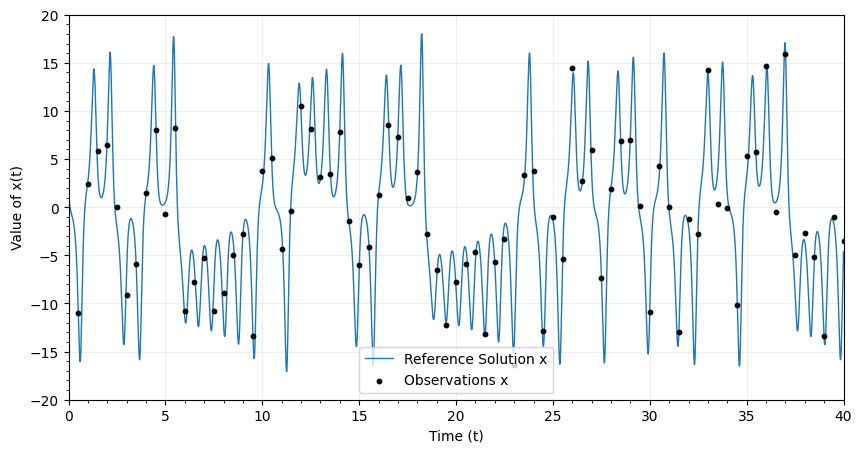

In [3]:
ref_sol, ref_ts = model.reference_solution
obs, obs_ts = model.observations

plt.figure(figsize=(10, 5))

plt.plot(ref_ts, ref_sol[:,0], linewidth=1, label='Reference Solution x')
plt.scatter(obs_ts, obs[:,0], s=10, c='Black', zorder=2, label='Observations x')

plt.xlabel('Time (t)')
plt.xlim(0, 40)
plt.ylabel('Value of x(t)')
plt.ylim(-20, 20)
plt.legend()
plt.minorticks_on()
plt.grid(alpha=0.2)

plt.show()

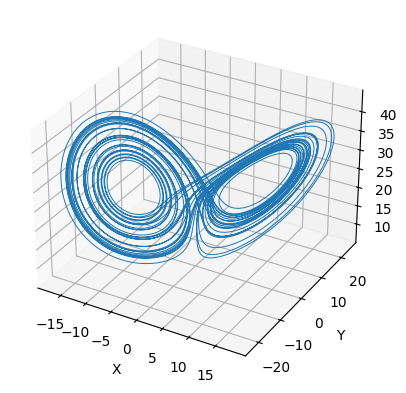

In [4]:

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot3D(ref_sol[:,0], ref_sol[:,1], ref_sol[:,2], linewidth=0.7)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

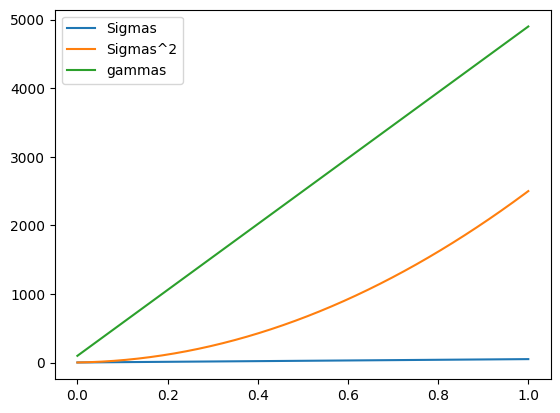

In [5]:
sigma_begin = 1
sigma_end = 50
N_tsteps = 150
sigmas = np.linspace(sigma_begin, sigma_end, N_tsteps)
taus = np.linspace(0, 1, N_tsteps)

dtau = taus[1] - taus[0]  # Time step (assuming uniform spacing)
dsigma_dtau = np.gradient(sigmas, dtau)

gammas = 2 * sigmas * dsigma_dtau

plt.figure()
plt.plot(taus, sigmas, label="Sigmas")
plt.plot(taus, sigmas**2, label="Sigmas^2")
plt.plot(taus, gammas, label="gammas")
plt.legend()
plt.show()

In [7]:

gauss_mix = GaussianMixture()
states, times = gauss_mix.filter(model, 3, 0.25, sigmas, gammas)

0, 0.0
Get Initialize states
1, 0.25
Predicting
Observation unavailable
2, 0.5
Predicting
Observation exists at this time
observation = [-11.02337975 -19.1947626   19.0406451 ]
3, 0.75
Predicting
Observation unavailable
4, 1.0
Predicting
Observation exists at this time
observation = [ 2.38248038  3.27075308 14.64067993]
5, 1.25
Predicting
Observation unavailable
6, 1.5
Predicting
Observation exists at this time
observation = [ 5.80358943 -1.32877489 26.35484732]
7, 1.75
Predicting
Observation unavailable
8, 2.0
Predicting
Observation exists at this time
observation = [ 6.43974791 13.19333067 11.2676985 ]
9, 2.25
Predicting
Observation unavailable
10, 2.5
Predicting
Observation exists at this time
observation = [ 0.05241744 -5.45602795 19.60605636]
11, 2.75
Predicting
Observation unavailable
12, 3.0
Predicting
Observation exists at this time
observation = [-9.08199626  0.32479805 31.93886256]


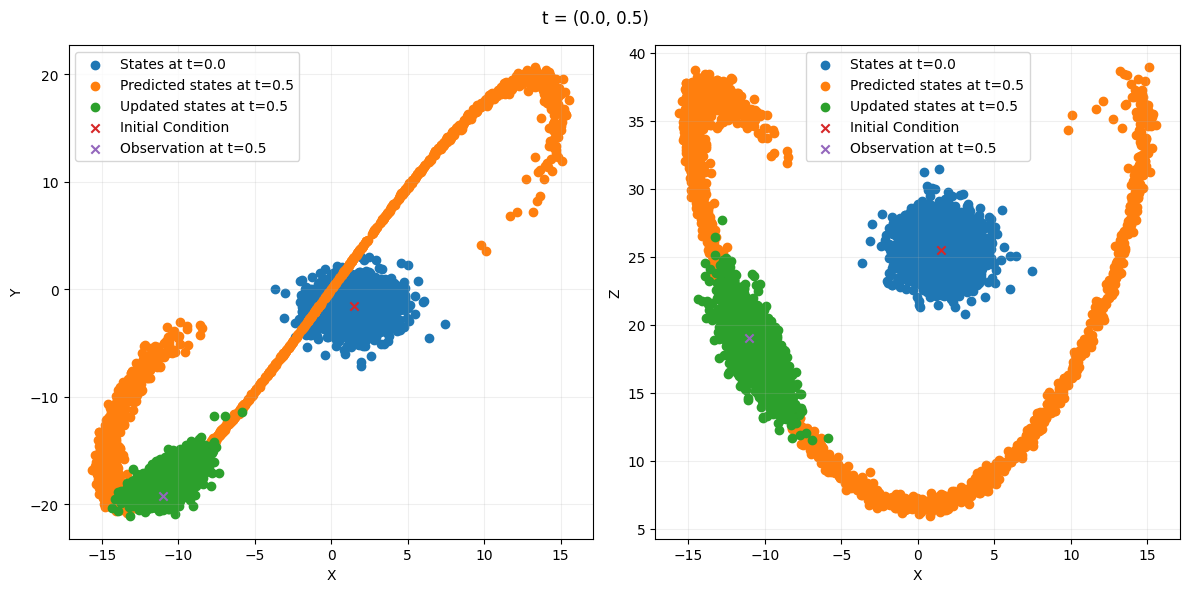

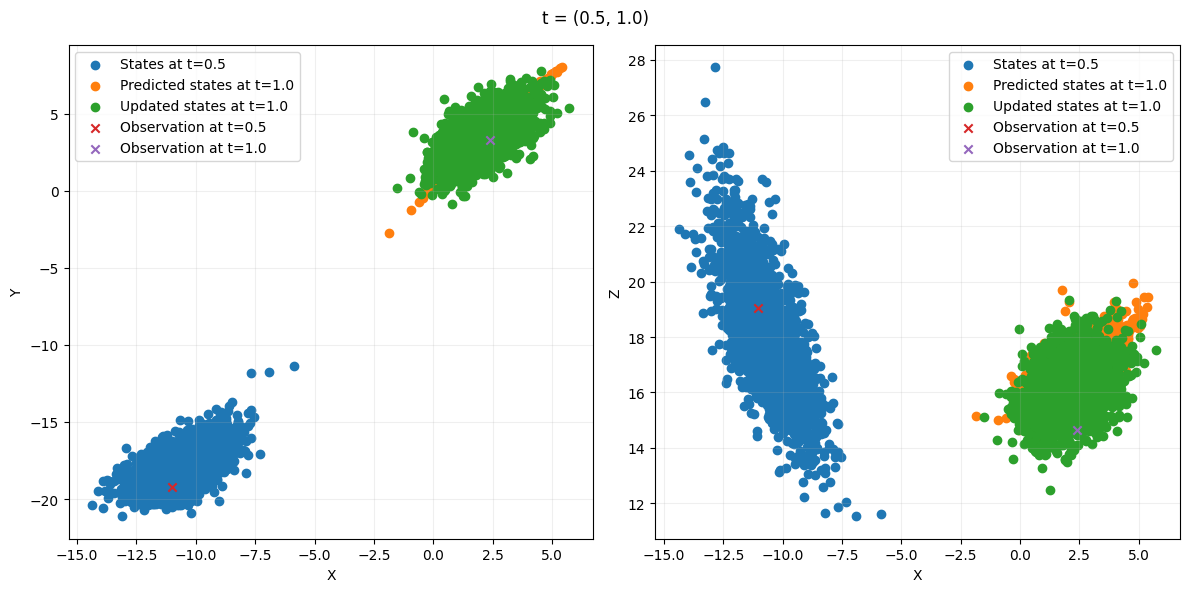

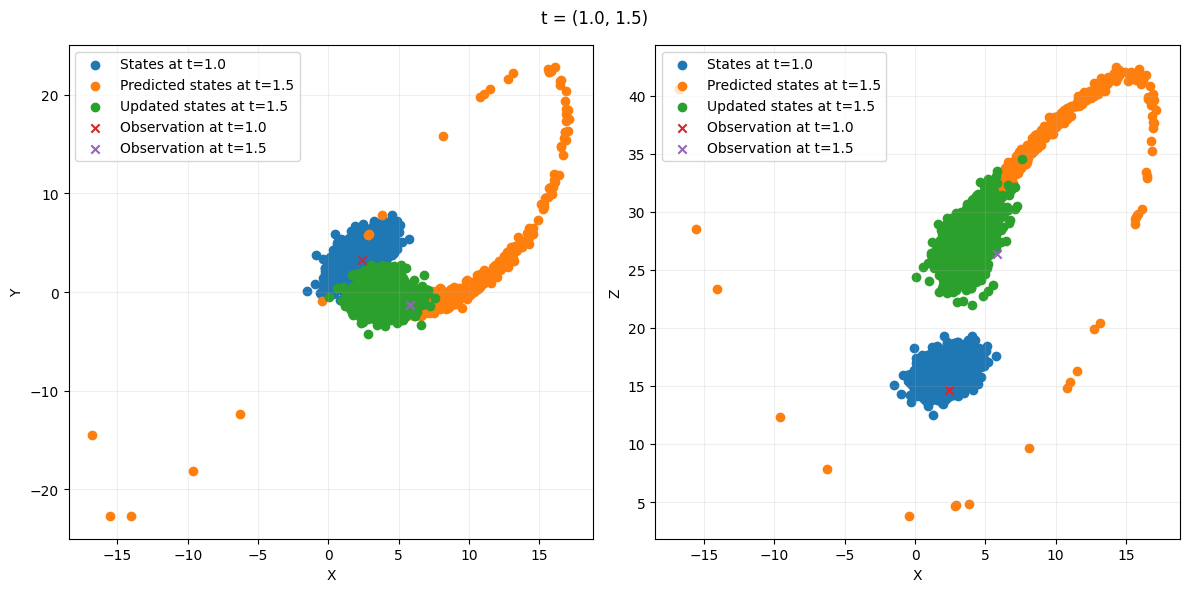

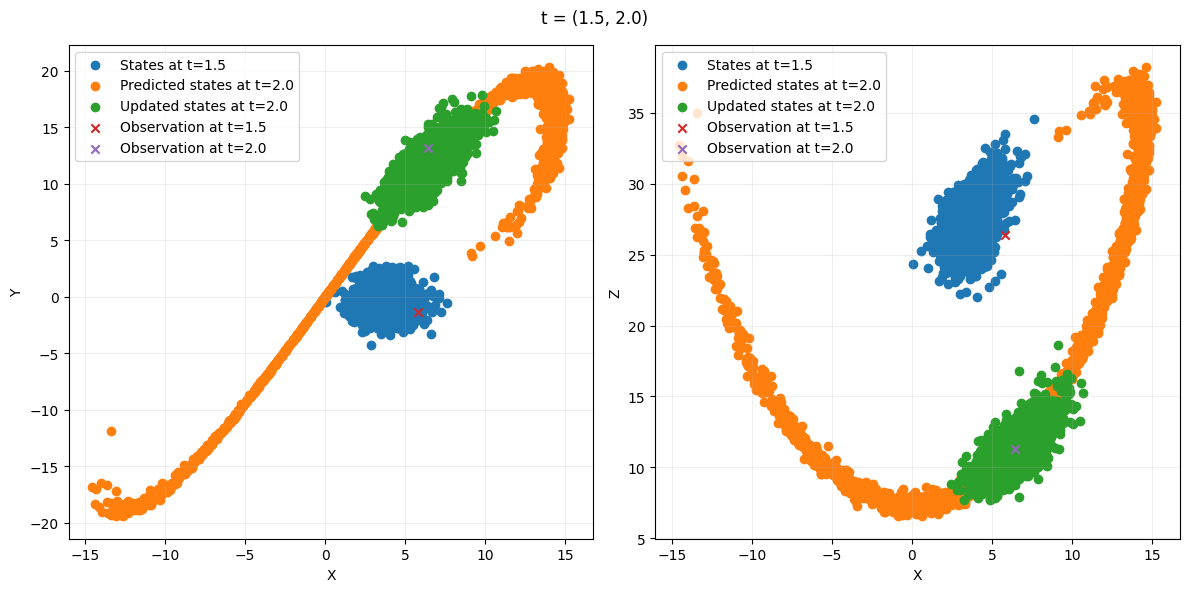

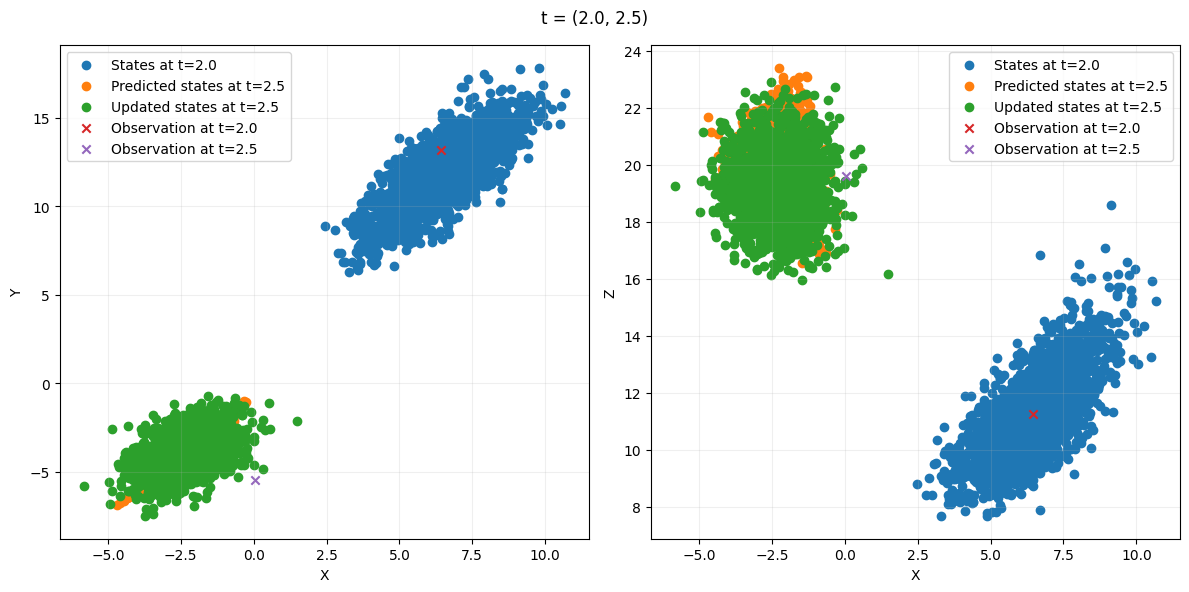

In [19]:
def plot_particles(idx1, idx2):

    predicted_states = model.predict(states[idx2-1], times[idx2-1], times[idx2])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    fig.suptitle(f"t = ({times[idx1]}, {times[idx2]})")

    ax1.scatter(states[idx1][:,0], states[idx1][:,1], label=f"States at t={times[idx1]}")
    ax1.scatter(predicted_states[:,0], predicted_states[:,1], label=f"Predicted states at t={times[idx2]}")
    ax1.scatter(states[idx2][:,0], states[idx2][:,1], label=f"Updated states at t={times[idx2]}")
    if idx1 == 0:
        ax1.scatter(model.init_cond[0], model.init_cond[1], marker='x', label="Initial Condition")
    else:
        ax1.scatter(obs[int(idx1/2) - 1][0], obs[int(idx1/2) - 1][1], marker='x', label=f"Observation at t={times[idx1]}")
    ax1.scatter(obs[int(idx2/2) - 1][0], obs[int(idx2/2) - 1][1], marker='x', label=f"Observation at t={times[idx2]}")

    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.grid(alpha=0.2)
    ax1.legend()

    ax2.scatter(states[idx1][:,0], states[idx1][:,2], label=f"States at t={times[idx1]}")
    ax2.scatter(predicted_states[:,0], predicted_states[:,2], label=f"Predicted states at t={times[idx2]}")
    ax2.scatter(states[idx2][:,0], states[idx2][:,2], label=f"Updated states at t={times[idx2]}")
    if idx1 == 0:
        ax2.scatter(model.init_cond[0], model.init_cond[2], marker='x', label="Initial Condition")
    else:
        ax2.scatter(obs[int(idx1/2) - 1][0], obs[int(idx1/2) - 1][2], marker='x', label=f"Observation at t={times[idx1]}")
    ax2.scatter(obs[int(idx2/2) - 1][0], obs[int(idx2/2) - 1][2], marker='x', label=f"Observation at t={times[idx2]}")

    ax2.set_xlabel("X")
    ax2.set_ylabel("Z")
    ax2.grid(alpha=0.2)
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_particles(0, 2)
plot_particles(2, 4)
plot_particles(4, 6)
plot_particles(6, 8)
plot_particles(8, 10)